In [16]:
!pip install -q networkx scipy

In [17]:
!pip install -q pandoc

# Epidemic Modeling Research
This notebook explores SIR and SIRI epidemic models on network graphs, including the impact of vaccination strategies using dominating sets.

In [18]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
import time
import random
import IPython
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.integrate import odeint
from pyvis.network import Network
from IPython.display import IFrame
from networkx.algorithms.dominating import dominating_set

# Configuration
%matplotlib inline

In [19]:
class EpidemicSimulator:
    def __init__(self, G):
        self.G = G
        self.A = nx.to_numpy_array(G)
        self.n = len(G)

    def run_siri_v(self, m, vaccinated, params, initials, mode="SIRI"):
        """Generalized SIRI/SIR simulation with vaccination support"""
        S, I, R = initials['S'].copy(), initials['I'].copy(), initials['R'].copy()
        history = []

        for _ in range(m):
            history.append([sum(S), sum(R), sum(I)])
            S, I, R = self._step(S, I, R, vaccinated, params, mode)

        return np.array(history), S, I, R

    def _step(self, S, I, R, vaccinated, p, mode):
        S_, I_, R_ = S.copy(), I.copy(), R.copy()
        for i in range(self.n):
            M, N = 1.0, 1.0
            neighbors = np.where(self.A[:, i] > 0)[0]

            # Parameter selection based on vaccination status
            beta_i = p['b'] if vaccinated[i] else p['beta']
            eps_i = p['e'] if vaccinated[i] else p['epsilon']
            gamma_i = p['g'] if vaccinated[i] else p['gamma']
            h_neighbor = p['h']

            for j in neighbors:
                # Neighbors' infectiousness
                beta_j = h_neighbor if vaccinated[j] else beta_i
                eps_j = h_neighbor if vaccinated[j] else eps_i
                M *= (1 - I[j] * beta_j)
                N *= (1 - I[j] * eps_j)

            S_[i] = S[i] * M
            if mode == "SIRI":
                I_[i] = S[i] * (1 - M) + I[i] * (1 - gamma_i) + R[i] * (1 - N)
            else: # SI mode
                I_[i] = 1 - S_[i]

        R_ = 1 - S_ - I_
        return S_, I_, R_

In [20]:
def plot_results(history, n, title, vline=None):
    plt.figure(figsize=(8, 5))
    t = np.arange(len(history))
    plt.plot(t, history[:, 2]/n, label="Infected")
    plt.plot(t, history[:, 0]/n, label="Susceptible")
    plt.plot(t, history[:, 1]/n, label="Recovered")
    if vline is not null:
        plt.axvline(vline, color="pink", linestyle="--", label="Vaccination")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Fraction")
    plt.legend()
    plt.show()

In [34]:
class VaccinationStrategy:
  def __init__(self, G):
    self.G = G
    self.A = nx.to_numpy_array(G)
    self.n = len(G)
  def select_vaccinated(self, dominating_set, percent):
    vaccinated = [False] * self.G.number_of_nodes()
    nI = int(self.G.number_of_nodes() * percent)
    ids = list(dominating_set)
    random.shuffle(ids)
    ids = ids[:nI]
    for idx in ids:
        vaccinated[idx] = True
    if len(ids) < nI:
          remaining = list(set(list(range(self.G.number_of_nodes()))) - set(ids))
          random.shuffle(remaining)
          remaining = remaining[:nI-len(ids)]
          for idx in remaining:
            vaccinated[idx] = True

    return vaccinated

class NoVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)
    def select_vaccinated(self, dominating_set, percent):
        return [False] * self.G.number_of_nodes()

class DegreeVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)

    def select_vaccinated(self, dominating_set, percent):
        vaccinated = [False] * self.G.number_of_nodes()
        nI = int(self.G.number_of_nodes() * percent)
        ids = list(dominating_set)
        # get the degrees of nodes in the dominating set
        degrees = [self.G.degree(node) for node in ids]
        #select the top nI nodes based on their degrees from the dominatingset
        ids = [x for _, x in sorted(zip(degrees, ids), reverse=True)]
        ids = ids[:nI]
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
          remaining = list(set(list(range(self.G.number_of_nodes()))) - set(ids))
          random.shuffle(remaining)
          remaining = remaining[:nI-len(ids)]
          for idx in remaining:
            vaccinated[idx] = True
        return vaccinated

class DegreeCentralityVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)

    def select_vaccinated(self, dominating_set, percent):
        vaccinated = [False] * self.G.number_of_nodes()
        nI = int(self.G.number_of_nodes() * percent)
        ids = list(dominating_set)
        # get the centrality score of nodes in the dominating set
        scores = [nx.degree_centrality(self.G)[node] for node in ids]
        #select the top nI nodes based on their scores
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)]
        ids = ids[:nI]
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
          remaining = list(set(list(range(self.G.number_of_nodes()))) - set(ids))
          random.shuffle(remaining)
          remaining = remaining[:nI-len(ids)]
          for idx in remaining:
            vaccinated[idx] = True
        return vaccinated

class BetweennessCentralityVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)

    def select_vaccinated(self, dominating_set, percent):
        vaccinated = [False] * self.G.number_of_nodes()
        nI = int(self.G.number_of_nodes() * percent)
        ids = list(dominating_set)
        # get the centrality score of nodes in the dominating set
        scores = [nx.betweenness_centrality(self.G)[node] for node in ids]
        #select the top nI nodes based on their scores
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)]
        ids = ids[:nI]
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
          remaining = list(set(list(range(self.G.number_of_nodes()))) - set(ids))
          random.shuffle(remaining)
          remaining = remaining[:nI-len(ids)]
          for idx in remaining:
            vaccinated[idx] = True
        return vaccinated

class ClosenessCentralityVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)

    def select_vaccinated(self, dominating_set, percent):
        vaccinated = [False] * self.G.number_of_nodes()
        nI = int(self.G.number_of_nodes() * percent)
        ids = list(dominating_set)
        # get the centrality score of nodes in the dominating set
        scores = [nx.closeness_centrality(self.G)[node] for node in ids]
        #select the top nI nodes based on their scores
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)]
        ids = ids[:nI]
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
          remaining = list(set(list(range(self.G.number_of_nodes()))) - set(ids))
          random.shuffle(remaining)
          remaining = remaining[:nI-len(ids)]
          for idx in remaining:
            vaccinated[idx] = True
        return vaccinated

class EigenVectorCentralityVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)

    def select_vaccinated(self, dominating_set, percent):
        vaccinated = [False] * self.G.number_of_nodes()
        nI = int(self.G.number_of_nodes() * percent)
        ids = list(dominating_set)
        # get the centrality score of nodes in the dominating set
        scores = [nx.eigenvector_centrality(self.G)[node] for node in ids]
        #select the top nI nodes based on their scores
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)]
        ids = ids[:nI]
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
          remaining = list(set(list(range(self.G.number_of_nodes()))) - set(ids))
          random.shuffle(remaining)
          remaining = remaining[:nI-len(ids)]
          for idx in remaining:
            vaccinated[idx] = True
        return vaccinated
        
class RandomVaccinationStrategy(VaccinationStrategy):
    def __init__(self, G):
        super().__init__(G)
    def select_vaccinated(self, dominating_set, percent):
        vaccinated = [False] * self.G.number_of_nodes()
        nI = int(self.G.number_of_nodes() * percent)
        ids = list(range(self.G.number_of_nodes()))
        random.shuffle(ids)
        for idx in ids[:nI]:
            vaccinated[idx] = True
        return vaccinated

class VaccinationStrategyFactory:
    def __init__(self, G):
        self.G = G
    def get_strategy(self, strategy_name):
        if strategy_name == "no_vac":
            return NoVaccinationStrategy(self.G)
        elif strategy_name == "degree":
            return DegreeVaccinationStrategy(self.G)
        elif strategy_name == "degree_centrality":
            return DegreeCentralityVaccinationStrategy(self.G)
        elif strategy_name == "betweenness_centrality":
            return BetweennessCentralityVaccinationStrategy(self.G)
            
        elif strategy_name == "closeness_centrality":
            return ClosenessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "eigenvector_centrality":
            return EigenVectorCentralityVaccinationStrategy(self.G)
        elif strategy_name == "random":
            return RandomVaccinationStrategy(self.G)
        
        else:
            raise ValueError("Invalid vaccination strategy")

In [35]:
class RunEpidemic:
  def __init__(self, G=None):
    self.G = G

  def run_epidemic(self, stratey_name,  m, params, initials, mode="SIRI", dominatingset=True, top_k=.1):
    simulator = EpidemicSimulator(self.G)
    strategy = VaccinationStrategyFactory(self.G).get_strategy(stratey_name)
    if dominatingset:
      vaccinated = strategy.select_vaccinated(dominating_set(self.G), top_k)
    else:
      vaccinated = strategy.select_vaccinated(list(range(self.G.number_of_nodes())), top_k)

    history, S, I, R, = simulator.run_siri_v(m, vaccinated, params, initials, mode)
    return history, S, I, R

In [36]:
def visualize_graph(graph, p=None, title='Probability of being infected', mode=0):

    for node in graph.nodes:
        graph.nodes[node]['label'] = str(node)


    if p is not None:
        cmap = plt.get_cmap('viridis') # You can use 'plasma', 'magma', or 'coolwarm'
        norm = mcolors.Normalize(vmin=min(p), vmax=max(p))
        colors = [mcolors.to_hex(cmap(norm(v))) for v in p]

            # 4. Generate the Colorbar Plot
        if mode ==0:
            fig, ax = plt.subplots(figsize=(6, 1))
            fig.subplots_adjust(bottom=0.5)
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            fig.colorbar(sm, cax=ax, orientation='horizontal', label=title)

        else:

            vaccine_color =  mcolors.to_hex(cmap(norm(1)))

            # 2. Create the proxy artist (the rectangle)
            vaccine_patch = mpatches.Patch(color=vaccine_color, label="Dominating Set")

            # 3. Add it to your figure legend
            fig, ax = plt.subplots(figsize=(6, 1))
            ax.legend(handles=[vaccine_patch], loc='center', frameon=False)

        # 3. Apply labels and colors to the NetworkX nodes
        for i, node in enumerate(graph.nodes):
            graph.nodes[node]['label'] = str(node)
            graph.nodes[node]['font'] = {'color': '#000000', 'size': 20, 'align': 'middle'}
            graph.nodes[node]['color'] = colors[i]
            graph.nodes[node]['title'] = f"Value: {p[i]}" # Shows value on hover
    #nx.set_node_attributes(graph, "Node Label", "title") # Tooltip on hover
    net = Network(notebook=True,height='600px', width='800px', bgcolor='#FFFFFF', font_color='#000000', cdn_resources='remote')
    # 3. Load the NetworkX graph
    net.from_nx(graph)
    # 4. Optional: Add interactive physics UI
    # This allows you to tweak the "bounce" and "gravity" of nodes in the browser
    net.prep_notebook()
    #net.show_buttons(filter_=['physics'])
    # 5. Save and open the interactive HTML file
    net.toggle_physics(False)
    net.save_graph("my_graph.html")
    plt.show() # Shows the static colorbar
    return IPython.display.HTML(filename="my_graph.html")

In [37]:
!pip install -q pyvis

In [38]:
G=nx.read_weighted_edgelist('Dublin.txt')
A=nx.to_numpy_array(G)
G=nx.from_numpy_array(A)
n = len(G)

## RUnning Experiments

In [39]:
from networkx.algorithms.dominating import dominating_set

## SIR

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation Parameters
m_initial = 3
m_after = 500
params = {
    'beta': 0.025,
    'gamma': 0.015,
    'epsilon': 0.0,
    'b': 0.002,    # Infection rate (vaccinated)
    'g': 0.15,    # Recovery rate (vaccinated)
    'e': 0.000,   # Reinfection rate (vaccinated)
    'h': 0.002    # Neighborhood infectiousness
}
mode = "SIRI"

# Initial state
initial_S = np.ones(n)
initial_R = np.zeros(n)
initial_I = np.zeros(n)
initial_I[0] = 1
initial_S[0] = 0
initials = {'S': initial_S, 'I': initial_I, 'R': initial_R}

# Define strategies to test
strategies = ['no_vac', 'degree', 'degree_centrality', 'random',"closeness_centrality","betweenness_centrality","eigenvector_centrality"]
results_SIR = {}

runner = RunEpidemic()
# Note: Fixing the __init__ typo in RunEpidemic from previous cell if needed
runner.G = G


for i, strat in enumerate(strategies):
    # Run simulation
    history, S_f, I_f, R_f = runner.run_epidemic(
        stratey_name=strat,
        m=m_after,
        params=params,
        initials=initials,
        mode=mode,
        dominatingset=True
    )
    results_SIR[strat]={"history":history, "S_f":S_f, "I_f":I_f, "R_f":R_f}
    # Plotting


In [41]:
def plot_results(results_SIR, strategies):
    fig, axes = plt.subplots(4,2,figsize=(10, 10))
    axes = [axes[i][j] for i in range(4) for j in range(2)]
    for i, strat in enumerate(strategies):
        ax = axes[i]
        plt.subplot(4, 2, i+1)
        t = np.arange(len(results_SIR[strat]["history"]))
        ax.plot(t, results_SIR[strat]["history"][:, 2]/n, label="Infected")
        ax.plot(t,results_SIR[strat]["history"][:, 0]/n, label="Susceptible")
        ax.plot(t, results_SIR[strat]["history"][:, 1]/n, label="Recovered")
        ax.set_title(f"Strategy: {strat}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Population Fraction")
        ax.legend(loc='center right')
    axes[-1].set_visible(False)
    plt.tight_layout()
    plt.show()

In [42]:
styles = [
    '-',                      # Solid
    '--',                     # Dashed
    ':',                      # Dotted
    '-.',                     # Dash-dot
    (0, (5, 10)),             # Long Dash
    (0, (1, 1)),              # Dense Dot
    (0, (3, 5, 1, 5, 1, 5))   # Triple-mix
]
def plot_global_attack(results_SIR, strategies):
    fig, ax = plt.subplots()
    ax.set_yscale('logit')
    for i, strat in enumerate(strategies):
        # Plotting
        t = np.arange(len(results_SIR[strat]["history"]))
        ax.plot(t, (results_SIR[strat]["history"][:, 2]+results_SIR[strat]["history"][:, 1])/n, ls = styles[i], label=strat)
        ax.set_title(f"Recovered+Infected")
        ax.set_xlabel("Time")
        ax.set_ylabel("Population Fraction")
        ax.legend()
    
    #plt.tight_layout()
    plt.show()

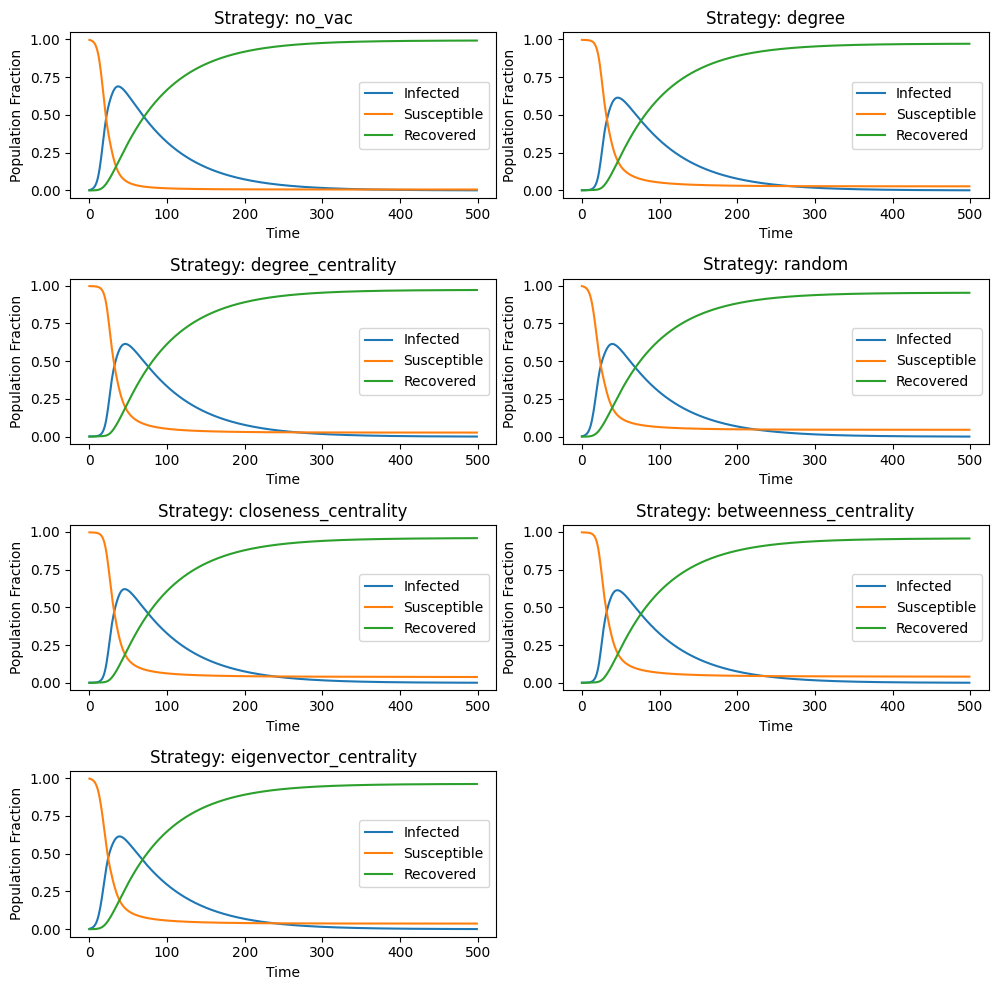

In [43]:
plot_results(results_SIR, strategies)

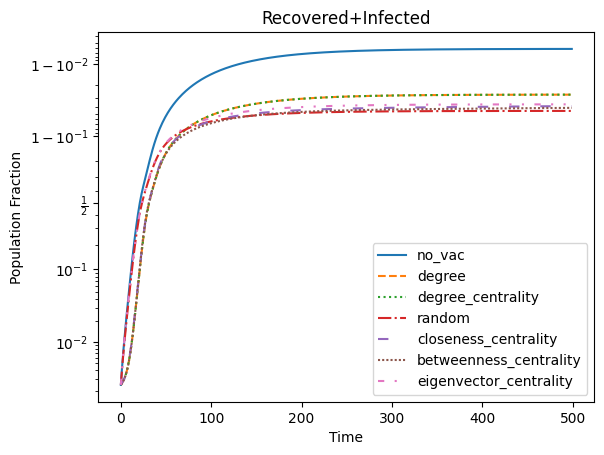

In [44]:
plot_global_attack(results_SIR, strategies)

In [45]:
import pandas as pd
import seaborn as sns
def plot_attack_histogram(results, strategies):
    ts = []
    mms = []
    target = .8
    fig, ax = plt.subplots()

    for i, strat in enumerate(strategies):
        y = results[strat]["history"][:, 2]
        #print(y)
        
        # Finds the index of the first maximum value
        t = np.argmax(y)
        mm = y[t]
        
        #print(strat, t, mm)
        ts.append(t)


    df = pd.DataFrame({"strategy":strategies, "times":ts})
    sns.barplot(data=df, x="strategy", y="times", ax=ax)

    # 2. Add Labels and Title
    ax.set_title(f'Time to reach {target*100}% Infection', fontsize=14, pad=15)
    ax.set_xlabel('Mitigation Strategy', fontsize=12)
    ax.set_ylabel('Time Steps (t)', fontsize=12)

    # 3. Rotate x-tick labels
    # 45 degrees is usually best for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout() # Prevents labels from being cut off
    plt.show()

C:\Users\hassa\AppData\Local\Temp\ipykernel_23268\942889569.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


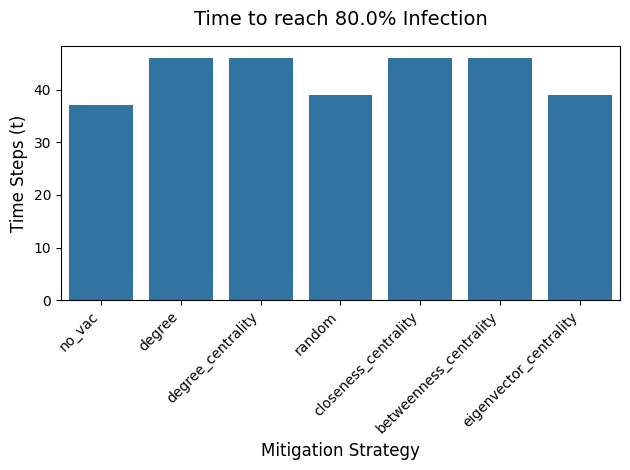

In [46]:
plot_attack_histogram(results_SIR, strategies)

## SI model

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration for SI Experiment
m_steps = 500
mode = "SI"

# SI Parameters
params = {
    'beta': 0.025,
    'b': 0.0020,
    'h': 0.002,
    'gamma': 0.0,
    'g': 0.0,
    'e': 0.0,
    'epsilon': 0.0
}
results_SI = {}

# Initial state
initial_S = np.ones(n)
initial_R = np.zeros(n)
initial_I = np.zeros(n)
initial_I[0] = 1
initial_S[0] = 0
initials = {'S': initial_S, 'I': initial_I, 'R': initial_R}

# Run comparison
strategies = ['no_vac', 'degree', 'degree_centrality', 'random',"closeness_centrality","betweenness_centrality","eigenvector_centrality"]
runner = RunEpidemic(G)


for i, strat in enumerate(strategies):
    # Run simulation
    history, S_f, I_f, R_f = runner.run_epidemic(
        stratey_name=strat,
        m=m_after,
        params=params,
        initials=initials,
        mode=mode,
        dominatingset=True
    )
    results_SI[strat]={"history":history, "S_f":S_f, "I_f":I_f, "R_f":R_f}

    

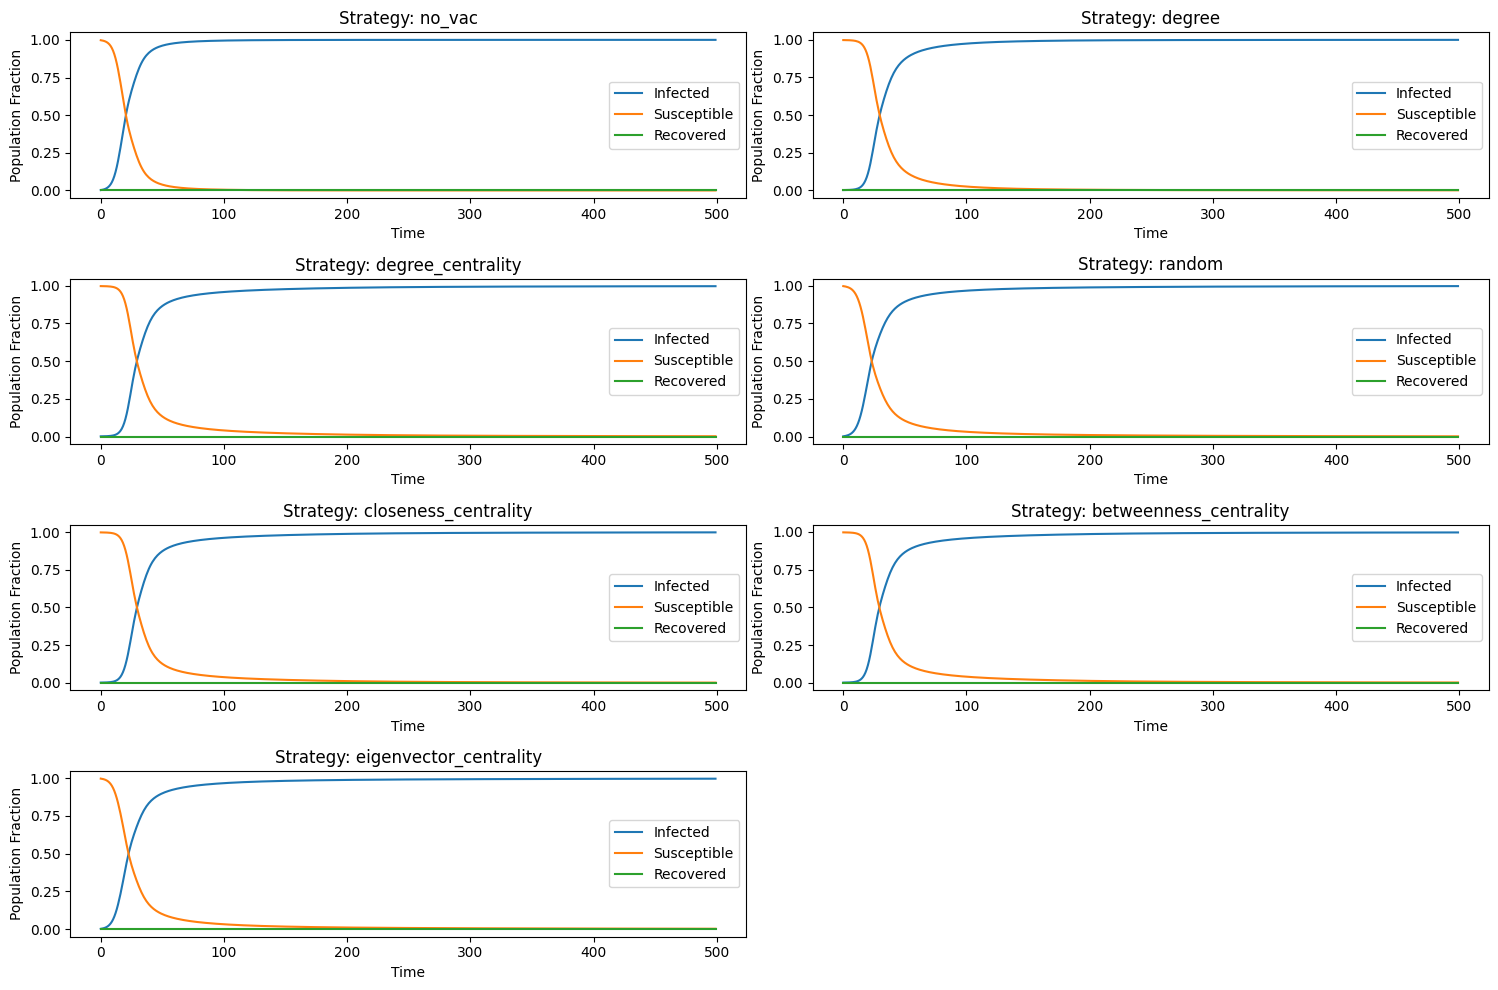

In [80]:
plot_results(results_SI, strategies)

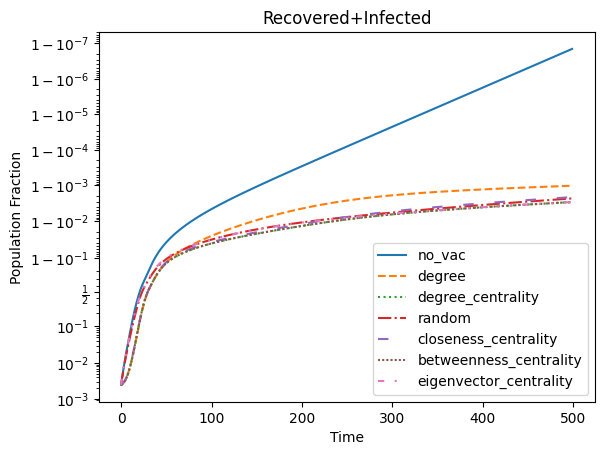

In [158]:
plot_global_attack(results_SI, strategies)

C:\Users\hassa\AppData\Local\Temp\ipykernel_28192\942889569.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


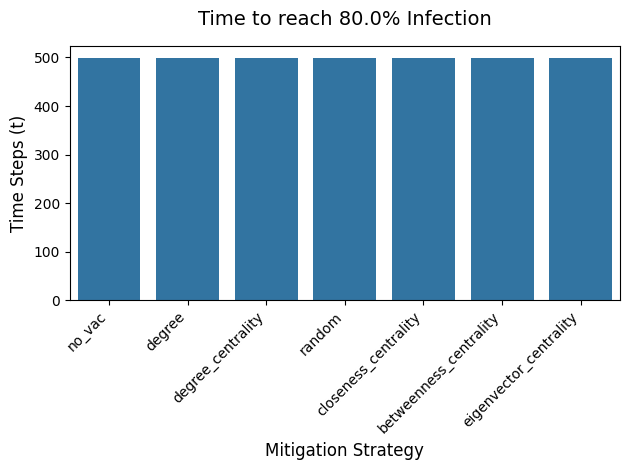

In [164]:
plot_attack_histogram(results_SI, strategies)

## SIRI Model with vaccination

In [82]:
# SIR Parameters
mode = "SIRI"
m_steps = 500

params = {
    'beta': 0.025,
    'gamma': 0.015,
    'epsilon': 0.001,
    'b': 0.002,
    'g': 0.0015,
    'e': 0.0007,
    'h': 0.002
}
results_SIRI={}
# Initial state
initial_S = np.ones(n)
initial_R = np.zeros(n)
initial_I = np.zeros(n)
initial_I[0] = 1
initial_S[0] = 0
initials = {'S': initial_S, 'I': initial_I, 'R': initial_R}

# Run experiments for SIR strategies
strategies = ['no_vac', 'degree', 'degree_centrality', 'random',"closeness_centrality","betweenness_centrality","eigenvector_centrality"]
runner = RunEpidemic(G)

for i, strat in enumerate(strategies):
    # Run simulation
    history, S_f, I_f, R_f = runner.run_epidemic(
        stratey_name=strat,
        m=m_after,
        params=params,
        initials=initials,
        mode=mode,
        dominatingset=True
    )
    results_SIRI[strat]={"history":history, "S_f":S_f, "I_f":I_f, "R_f":R_f}

    

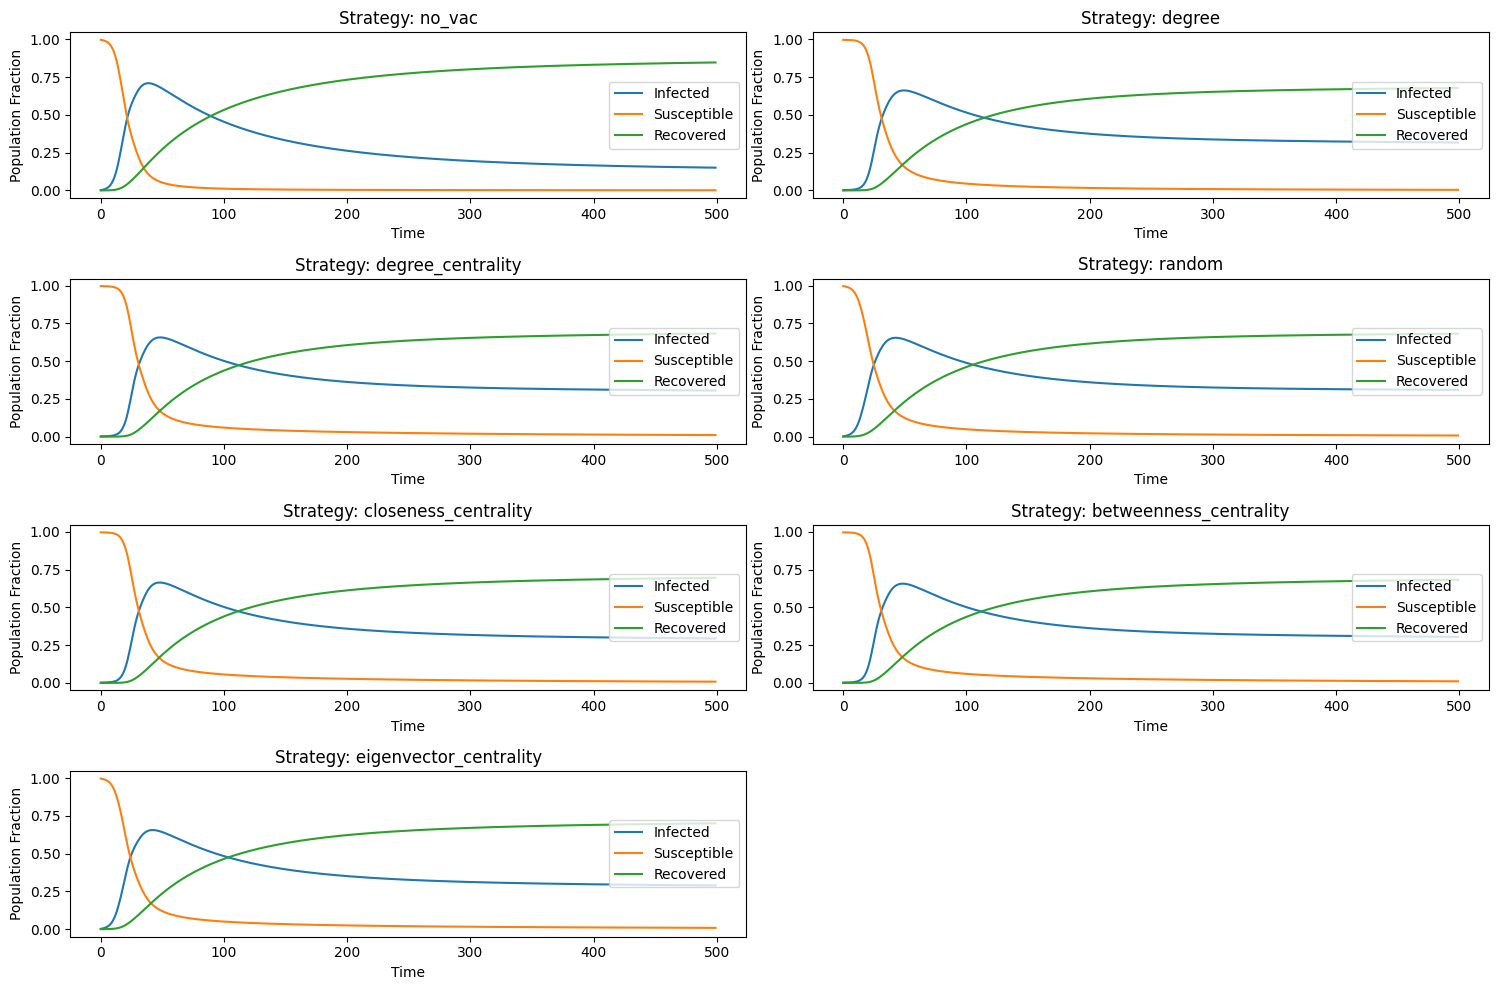

In [84]:
plot_results(results_SIRI, strategies)

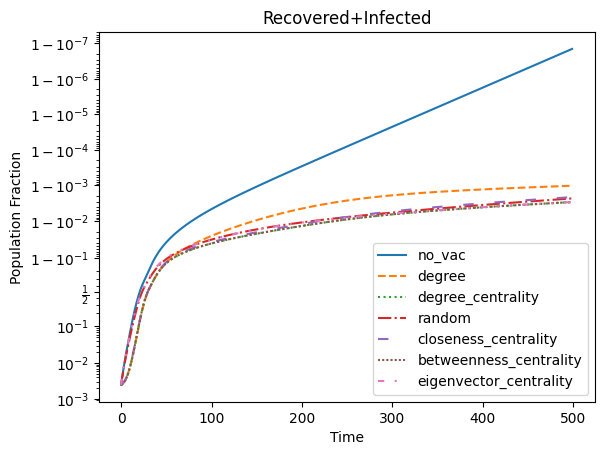

In [179]:
plot_global_attack(results_SI, strategies)

C:\Users\hassa\AppData\Local\Temp\ipykernel_28192\942889569.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


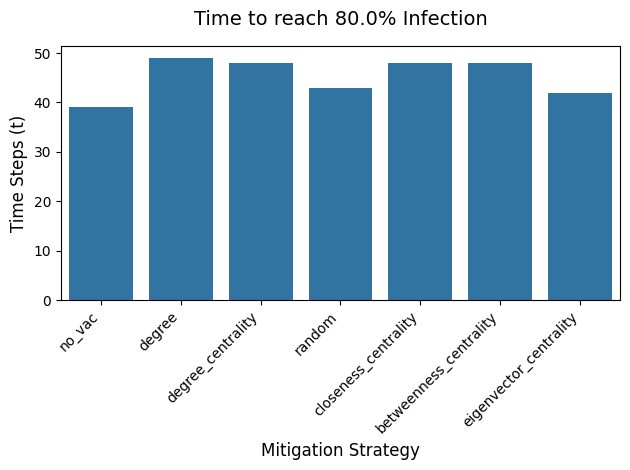

In [180]:
plot_attack_histogram(results_SIRI, strategies)